# PERISCAN-II Demo Note:

This demo uses cancer samples drawn from the validation set of the best-performing fold in cross-validation; none of the samples were used in the corresponding model's training. Due to file size constraints, only a subset of representative samples is included, with cells pre-filtered to the five immune cell types used for modeling and restricted to the corresponding feature gene sets. This demo is intended to illustrate code usability and the complete inference pipeline, including data input, model loading, ten-class tissue-of-origin prediction output, and result visualization. The reported performance metrics do not reflect the overall results presented in the manuscript.

In [1]:
import warnings
warnings.filterwarnings('ignore')


import os
import json
import time
import math
import traceback
import itertools
from pathlib import Path
from collections import defaultdict
import shutil

import numpy as np
import pandas as pd
import scipy
from scipy import stats

# model
from sklearn.model_selection import train_test_split, KFold
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)


import matplotlib.pyplot as plt
from matplotlib import gridspec
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR


import scanpy as sc
import anndata as ad


from tqdm import tqdm

In [2]:
#load anndata
adata_val=sc.read_h5ad('/data/Periscan_2_demo.h5ad')

In [3]:
adata_val

AnnData object with n_obs × n_vars = 112765 × 710
    obs: 'sample_id', 'disease', 'annotation', 'disease_1'

In [6]:
adata_val.obs['sample_id']

2307253    30
2307255    30
2307260    30
2307261    30
2307262    30
           ..
2304620    22
2304624    22
2304626    22
3069068    20
3095791    12
Name: sample_id, Length: 112765, dtype: category
Categories (50, object): ['21', '36', '43', '9', ..., '13', '14', '16', '22']

In [8]:
#Load PERISCAN-II feature gene set
import pickle

with open('/data/Periscan_2_genes.pkl', 'rb') as f:
    gene_lists_p2 = pickle.load(f)

In [9]:
#Run inference on validation cohort
from periscan_2_inference import run_inference

true_labels = (
    adata_val.obs[['sample_id', 'disease_1']]
    .drop_duplicates()
    .set_index('sample_id')['disease_1']
    .to_dict()
)

results_df = run_inference(
    adata       = adata_val,
    gene_lists  = gene_lists_p2,
    model_path  = '/data/Periscan_2_model.pt',
    true_labels = true_labels,
    results_dir = '/results',
    batch_size  = 8,
)

Device: cuda
Model loaded: 205,839 parameters

PERISCAN-II Inference Results
sample_id top1_pred top2_pred top3_pred  confidence
        1      CESC      STAD      BLCA      0.7812
       10      LUCA      COAD       NPC      0.4307
       11      STAD      LUCA      COAD      0.6679
       12      BLCA      HNSC      CESC      0.5732
       13      HNSC      BLCA      LIHC      0.7157
       14      ESCA      LUCA      COAD      0.6995
       15      LUCA      LIHC      ESCA      0.4531
       16      PAAD      COAD      LUCA      0.5016
       17      COAD      ESCA      LUCA      0.4215
       18      LUCA      CESC      COAD      0.5383
       19      LIHC      COAD      ESCA      0.6652
        2       NPC      HNSC      COAD      0.5257
       20      ESCA      LIHC      COAD      0.6698
       21      PAAD      LIHC      COAD      0.7341
       22      CESC      LUCA      COAD      0.8052
       23      STAD      HNSC      PAAD      0.4229
       24      LIHC      ESCA      COAD

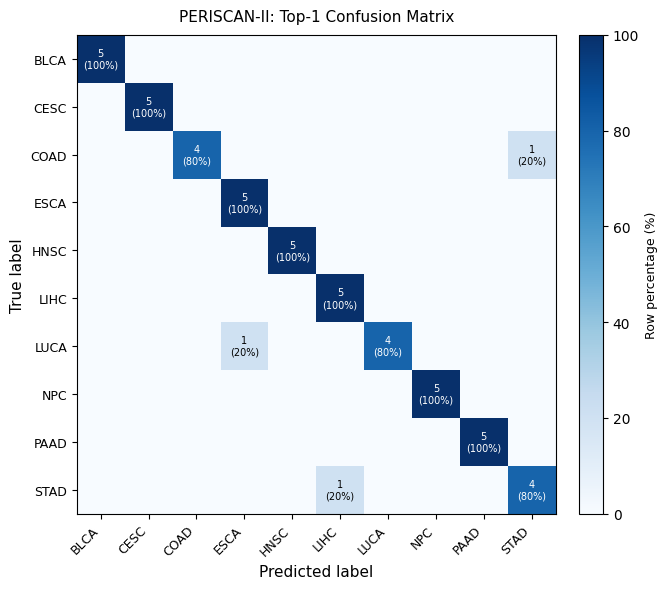

Saved: /results/periscan_2/confusion_matrix_top1.pdf


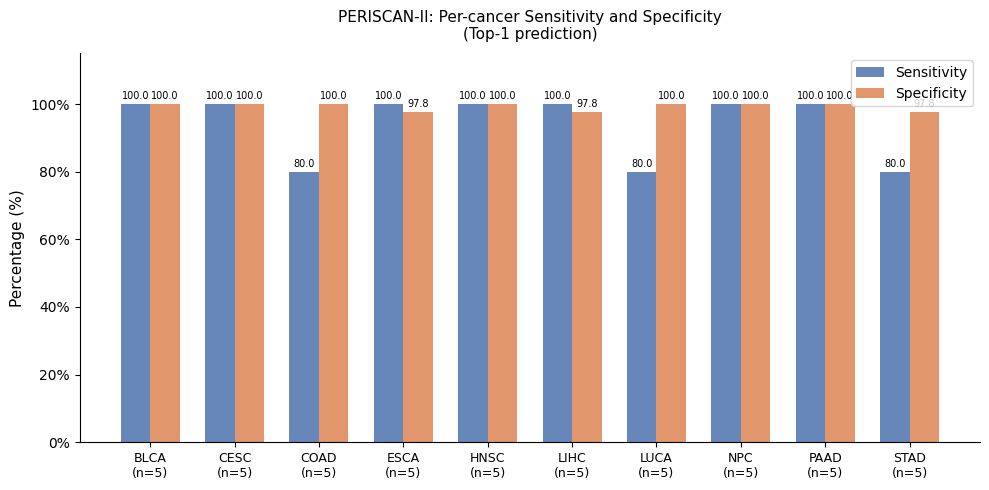

Saved: /results/periscan_2/sensitivity_specificity.pdf


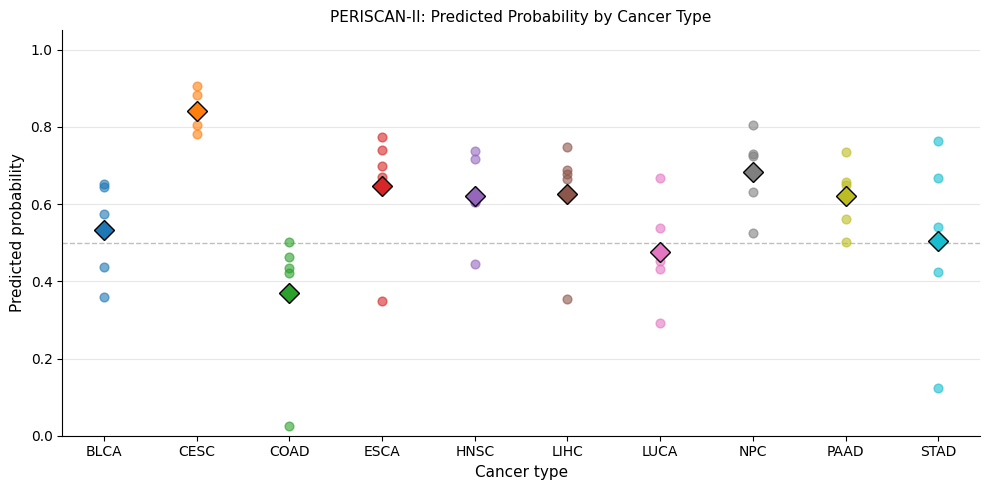

Saved: /results/periscan_2/probability_distribution.pdf

PERISCAN-II Summary
        metric  correct  total accuracy
Top-1 accuracy       47     50    94.0%
Top-2 accuracy       48     50    96.0%
Top-3 accuracy       48     50    96.0%

All outputs saved to: /results/periscan_2


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams.update(matplotlib.rcParamsDefault)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42

CANCER_TYPES = ['BLCA', 'CESC', 'COAD', 'ESCA', 'HNSC',
                'LIHC', 'LUCA', 'NPC', 'PAAD', 'STAD']

OUTPUT_DIR = '/results/periscan_2'
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ── 1. Confusion matrix (top-1) ──────────────────────────────────────────────

def build_confusion_matrix(df):
    """Build top-1 confusion matrix (counts)."""
    n   = len(CANCER_TYPES)
    idx = {c: i for i, c in enumerate(CANCER_TYPES)}
    cm  = np.zeros((n, n), dtype=int)
    for _, row in df.iterrows():
        cm[idx[row['true_label']], idx[row['top1_pred']]] += 1
    return cm


def plot_confusion_matrix(cm, title, out_path):
    """Row-normalised confusion matrix annotated with count and percentage."""
    n      = len(CANCER_TYPES)
    cm_pct = cm / cm.sum(axis=1, keepdims=True).clip(min=1) * 100

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)

    for i in range(n):
        for j in range(n):
            if cm[i, j] > 0:
                color = 'white' if cm_pct[i, j] > 55 else 'black'
                ax.text(j, i, f'{cm[i,j]}\n({cm_pct[i,j]:.0f}%)',
                        ha='center', va='center', fontsize=7, color=color)

    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(CANCER_TYPES, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(CANCER_TYPES, fontsize=9)
    ax.set_xlabel('Predicted label', fontsize=11)
    ax.set_ylabel('True label', fontsize=11)
    ax.set_title(title, fontsize=11, pad=10)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Row percentage (%)', fontsize=9)

    fig.tight_layout()
    fig.savefig(out_path, format='pdf', bbox_inches='tight')
    plt.show()
    print(f"Saved: {out_path}")


cm = build_confusion_matrix(results_df)
plot_confusion_matrix(
    cm,
    title    = 'PERISCAN-II: Top-1 Confusion Matrix',
    out_path = os.path.join(OUTPUT_DIR, 'confusion_matrix_top1.pdf'),
)


# ── 2. Sensitivity & specificity ─────────────────────────────────────────────

def compute_sens_spec(df):
    """Per-cancer top-1 sensitivity and specificity."""
    records = []
    for cancer in CANCER_TYPES:
        tp = ((df['true_label'] == cancer) & (df['top1_pred'] == cancer)).sum()
        fn = ((df['true_label'] == cancer) & (df['top1_pred'] != cancer)).sum()
        fp = ((df['true_label'] != cancer) & (df['top1_pred'] == cancer)).sum()
        tn = ((df['true_label'] != cancer) & (df['top1_pred'] != cancer)).sum()
        records.append({
            'cancer':      cancer,
            'n':           tp + fn,
            'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0.0,
            'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        })
    return pd.DataFrame(records)


def plot_sens_spec(metrics_df, out_path):
    """Grouped bar chart of per-cancer sensitivity and specificity."""
    x, width = np.arange(len(CANCER_TYPES)), 0.35
    fig, ax  = plt.subplots(figsize=(10, 5))

    bars_sens = ax.bar(x - width/2, metrics_df['sensitivity']*100, width,
                       label='Sensitivity', color='#4C72B0', alpha=0.85)
    bars_spec = ax.bar(x + width/2, metrics_df['specificity']*100, width,
                       label='Specificity', color='#DD8452', alpha=0.85)

    for bar in list(bars_sens) + list(bars_spec):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
                f'{h:.1f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f'{c}\n(n={metrics_df.loc[metrics_df.cancer==c,"n"].values[0]})'
         for c in CANCER_TYPES], fontsize=9)
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_ylabel('Percentage (%)', fontsize=11)
    ax.set_title('PERISCAN-II: Per-cancer Sensitivity and Specificity\n'
                 '(Top-1 prediction)', fontsize=11, pad=10)
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.tight_layout()
    fig.savefig(out_path, format='pdf', bbox_inches='tight')
    plt.show()
    print(f"Saved: {out_path}")


metrics_df = compute_sens_spec(results_df)
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'sensitivity_specificity.csv'), index=False)
plot_sens_spec(metrics_df, os.path.join(OUTPUT_DIR, 'sensitivity_specificity.pdf'))


# ── 3. Probability distributions ─────────────────────────────────────────────

def plot_prob_distributions(df, out_path):
    """Predicted probability distributions for all cancer types shown as strip plots."""
    fig, ax = plt.subplots(figsize=(10, 5))
    colors  = plt.cm.tab10(np.linspace(0, 1, len(CANCER_TYPES)))

    for i, cancer in enumerate(CANCER_TYPES):
        pos = df.loc[df['true_label'] == cancer, f'prob_{cancer}'].values
        ax.scatter(
            [cancer] * len(pos), pos,
            color=colors[i], alpha=0.6, s=40, zorder=3
        )
        ax.plot(
            [cancer], [pos.mean()],
            marker='D', color=colors[i],
            markersize=10, markeredgecolor='black', zorder=4
        )

    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Cancer type', fontsize=11)
    ax.set_ylabel('Predicted probability', fontsize=11)
    ax.set_title('PERISCAN-II: Predicted Probability by Cancer Type', fontsize=11)
    ax.axhline(0.5, color='gray', linestyle='--', lw=1, alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.tight_layout()
    fig.savefig(out_path, format='pdf', bbox_inches='tight')
    plt.show()
    print(f"Saved: {out_path}")


plot_prob_distributions(results_df, os.path.join(OUTPUT_DIR, 'probability_distribution.pdf'))


# ── 4. Top-k accuracy summary ────────────────────────────────────────────────

n    = len(results_df)
top1 = (results_df['true_label'] == results_df['top1_pred']).sum()
top2 = results_df.apply(lambda r: r['true_label'] in [r['top1_pred'], r['top2_pred']], axis=1).sum()
top3 = results_df.apply(lambda r: r['true_label'] in [r['top1_pred'], r['top2_pred'], r['top3_pred']], axis=1).sum()

summary = pd.DataFrame({
    'metric':   ['Top-1 accuracy', 'Top-2 accuracy', 'Top-3 accuracy'],
    'correct':  [top1, top2, top3],
    'total':    [n, n, n],
    'accuracy': [f'{top1/n:.1%}', f'{top2/n:.1%}', f'{top3/n:.1%}'],
})
summary.to_csv(os.path.join(OUTPUT_DIR, 'topk_accuracy.csv'), index=False)

print("\n" + "="*50)
print("PERISCAN-II Summary")
print("="*50)
print(summary.to_string(index=False))
print(f"\nAll outputs saved to: {OUTPUT_DIR}")